# Évaluation des modèles U-Net — ISIC 2016

**Objectif** : Évaluer rigoureusement les modèles U-Net (baseline et final) sur le **vrai jeu de test ISBI 2016** (379 images),
extraire les courbes d'apprentissage depuis les fichiers JSON d'entraînement, et produire toutes les données nécessaires au mémoire.

**Dataset** :
- Entraînement : 900 images (split interne 80/20 → 720 train / 180 val)
- Test : 379 images (jeu de test officiel ISBI 2016, jamais vu pendant l'entraînement)

**Sections** :
1. Configuration et chargement des données
2. Courbes d'apprentissage (extraction depuis JSON)
3. Évaluation sur le jeu de test officiel (379 images)
4. Analyse par sous-groupes
5. Visualisations qualitatives
6. Tableau comparatif final (K-means vs U-Net)

---

In [2]:
import numpy as np
import json
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Chemins ──
BASE = Path(".").resolve()
MODELS_DIR = BASE / "models"
IMG_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_Data"
MASK_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_GroundTruth"
TEST_IMG_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Test_Data"
TEST_MASK_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Test_GroundTruth"

IMG_SIZE = 256

print(f"Train : {len(list(IMG_DIR.glob('*.jpg')))} images")
print(f"Test  : {len(list(TEST_IMG_DIR.glob('*.jpg')))} images")
print(f"Modèles JSON : {len(list(MODELS_DIR.glob('*.json')))}")
print(f"Modèles .keras : {[p.name for p in MODELS_DIR.glob('*.keras')]}")

Train : 900 images
Test  : 379 images
Modèles JSON : 24
Modèles .keras : ['baseline_f64-d4-skip-bce+dice.keras']


In [3]:
# ═══════════════════════════════════════════════════════════════
# Fonctions utilitaires
# ═══════════════════════════════════════════════════════════════

def dice(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return 2.0 * inter / denom if denom > 0 else 1.0

def iou(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return inter / union if union > 0 else 1.0

def pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fp = np.sum((1 - y_true) * y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fn = np.sum(y_true * (1 - y_pred))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


# ── Custom objects pour charger les modèles Keras ──
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

CUSTOM_OBJECTS = {
    "dice_coefficient": dice_coefficient,
    "iou_coefficient": iou_coefficient,
    "dice_loss": dice_loss,
    "bce_dice_loss": bce_dice_loss,
}

print("Fonctions chargées.")

Fonctions chargées.


---

## 1. Courbes d'apprentissage — Extraction depuis les fichiers JSON

On extrait les courbes train/val (loss, DSC) pour la baseline et le modèle final,
on calcule le temps d'entraînement total et on identifie le meilleur epoch.

In [4]:
# ═══════════════════════════════════════════════════════════════
# Extraction des informations d'entraînement
# ═══════════════════════════════════════════════════════════════

def extract_model_info(json_path):
    """Extrait les informations d'entraînement d'un fichier JSON de modèle."""
    with open(json_path) as f:
        data = json.load(f)

    history = data["history"]
    n_epochs = len(history["dice_coefficient"])

    val_dices = history["val_dice_coefficient"]
    best_epoch = int(max(range(len(val_dices)), key=lambda i: val_dices[i])) + 1
    best_val_dice = val_dices[best_epoch - 1]

    return {
        "name": data["name"],
        "params": data["params"],
        "time_s": data["time_s"],
        "time_min": round(data["time_s"] / 60, 1),
        "n_epochs": n_epochs,
        "stopped_epoch": data.get("stopped_epoch", n_epochs),
        "best_epoch": best_epoch,
        "best_val_dice": round(best_val_dice, 4),
        "best_val_iou": round(data["best_val_iou"], 4),
        "final_train_dice": round(history["dice_coefficient"][-1], 4),
        "final_val_dice": round(history["val_dice_coefficient"][-1], 4),
        "final_train_loss": round(history["loss"][-1], 4),
        "final_val_loss": round(history["val_loss"][-1], 4),
        "epoch1_val_dice": round(history["val_dice_coefficient"][0], 4),
        "curves": {
            "train_dice": [round(v, 4) for v in history["dice_coefficient"]],
            "val_dice": [round(v, 4) for v in history["val_dice_coefficient"]],
            "train_loss": [round(v, 4) for v in history["loss"]],
            "val_loss": [round(v, 4) for v in history["val_loss"]],
        }
    }


# ── Extraire baseline et final ──
models_info = {}
for label, filename in [("baseline", "baseline_f64-d4-skip-bce+dice.json"),
                         ("final", "FINAL.json")]:
    path = MODELS_DIR / filename
    if path.exists():
        models_info[label] = extract_model_info(path)
    else:
        print(f"⚠ {path.name} non trouvé")

# ── Tous les modèles (temps d'entraînement) ──
all_models = {}
for json_file in sorted(MODELS_DIR.glob("*.json")):
    if ".ipynb_checkpoints" in str(json_file):
        continue
    try:
        info = extract_model_info(json_file)
        all_models[json_file.stem] = info
    except Exception as e:
        print(f"Erreur pour {json_file.name}: {e}")

# ── Affichage ──
print("=" * 60)
print("RÉSUMÉ DES MODÈLES")
print("=" * 60)

for label in ["baseline", "final"]:
    if label in models_info:
        info = models_info[label]
        print(f"\n{info['name']} :")
        print(f"  Params     : {info['params']:,}")
        print(f"  Temps      : {info['time_min']} min ({info['time_s']:.0f}s)")
        print(f"  Epochs     : {info['n_epochs']} (early stop: {info['stopped_epoch']})")
        print(f"  Best epoch : {info['best_epoch']}")
        print(f"  Val DSC    : {info['epoch1_val_dice']:.4f} (ep.1) → {info['best_val_dice']:.4f} (best)")
        print(f"  Val IoU    : {info['best_val_iou']:.4f}")

total_time = sum(m["time_s"] for m in all_models.values())
print(f"\nTemps total ({len(all_models)} expériences) : {total_time:.0f}s = {total_time/3600:.1f}h")

RÉSUMÉ DES MODÈLES

baseline (f64/d4/skip/bce+dice) :
  Params     : 31,402,497
  Temps      : 15.9 min (952s)
  Epochs     : 27 (early stop: 27)
  Best epoch : 26
  Val DSC    : 0.4278 (ep.1) → 0.8539 (best)
  Val IoU    : 0.7482

FINAL :
  Params     : 31,378,945
  Temps      : 28.6 min (1715s)
  Epochs     : 30 (early stop: 30)
  Best epoch : 30
  Val DSC    : 0.5150 (ep.1) → 0.8904 (best)
  Val IoU    : 0.8050

Temps total (24 expériences) : 20324s = 5.6h


### 1.1 Visualisation des courbes d'apprentissage

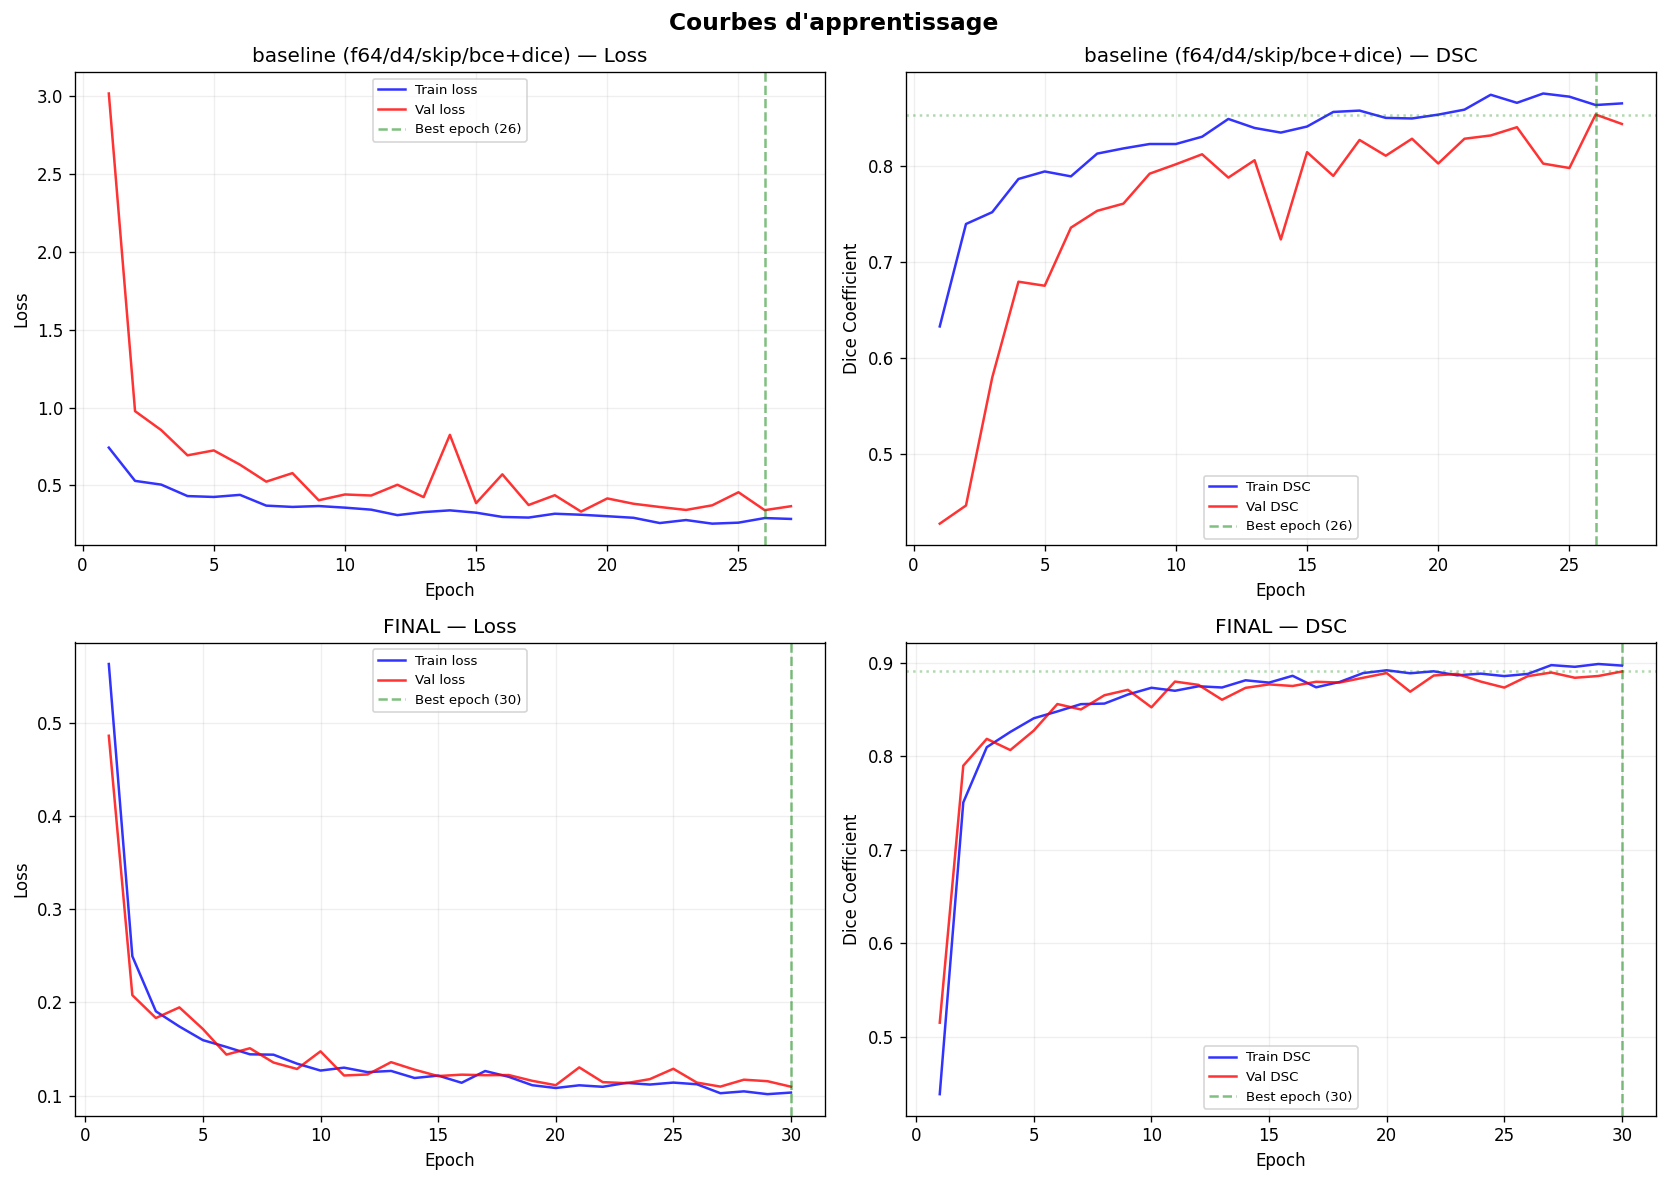

In [5]:
# ═══════════════════════════════════════════════════════════════
# Courbes d'apprentissage : Loss et DSC pour baseline et final
# ═══════════════════════════════════════════════════════════════

n_models = len(models_info)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models), squeeze=False)

for i, (label, info) in enumerate(models_info.items()):
    curves = info["curves"]
    epochs = range(1, len(curves["train_loss"]) + 1)
    best_ep = info["best_epoch"]

    # Loss
    ax = axes[i, 0]
    ax.plot(epochs, curves["train_loss"], "b-", label="Train loss", alpha=0.8)
    ax.plot(epochs, curves["val_loss"], "r-", label="Val loss", alpha=0.8)
    ax.axvline(best_ep, color="green", linestyle="--", alpha=0.5, label=f"Best epoch ({best_ep})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{info['name']} — Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    # DSC
    ax = axes[i, 1]
    ax.plot(epochs, curves["train_dice"], "b-", label="Train DSC", alpha=0.8)
    ax.plot(epochs, curves["val_dice"], "r-", label="Val DSC", alpha=0.8)
    ax.axvline(best_ep, color="green", linestyle="--", alpha=0.5, label=f"Best epoch ({best_ep})")
    ax.axhline(info["best_val_dice"], color="green", linestyle=":", alpha=0.3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice Coefficient")
    ax.set_title(f"{info['name']} — DSC")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle("Courbes d'apprentissage", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

---

## 2. Évaluation sur le jeu de test officiel ISBI 2016 (379 images)

On évalue chaque modèle `.keras` disponible sur les **379 images test** qui n'ont jamais été vues pendant l'entraînement.
C'est le protocole standard de la compétition ISBI 2016.

In [6]:
# ═══════════════════════════════════════════════════════════════
# Chargement du jeu de test officiel
# ═══════════════════════════════════════════════════════════════

test_img_paths = sorted(TEST_IMG_DIR.glob("*.jpg"))
test_mask_paths = sorted(TEST_MASK_DIR.glob("*.png"))

# Vérifier l'appariement images/masques
assert len(test_img_paths) == len(test_mask_paths), "Nombre d'images et masques test différent !"
print(f"Jeu de test : {len(test_img_paths)} images")

# Calculer le ratio lésion (rho) pour chaque image test
test_ratios = []
for mp in test_mask_paths:
    m = np.array(Image.open(mp).convert("L"))
    test_ratios.append(np.sum(m > 127) / m.size)
test_ratios = np.array(test_ratios)

print(f"Ratio lésion (rho) : mean={test_ratios.mean():.3f}, "
      f"median={np.median(test_ratios):.3f}, "
      f"[{test_ratios.min():.4f}, {test_ratios.max():.3f}]")

Jeu de test : 379 images
Ratio lésion (rho) : mean=0.282, median=0.235, [0.0027, 0.995]


In [9]:
# ═══════════════════════════════════════════════════════════════
# Évaluation image par image sur le test set
# ═══════════════════════════════════════════════════════════════

def evaluate_model_on_test(model, img_paths, mask_paths, ratios):
    """Évalue un modèle sur le jeu de test, image par image."""
    results = []
    for img_path, mask_path, rho in zip(img_paths, mask_paths, ratios):
        img = np.array(Image.open(img_path).convert("RGB").resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)).astype(np.float32) / 255.0

        gt = np.array(Image.open(mask_path).convert("L").resize(
            (IMG_SIZE, IMG_SIZE), Image.NEAREST))
        gt = (gt > 127).astype(np.float32)

        pred_prob = model.predict(img[np.newaxis, ...], verbose=0)[0, :, :, 0]
        pred_bin = (pred_prob >= 0.5).astype(np.float32)

        results.append({
            "image": img_path.stem,
            "dice": float(dice(gt, pred_bin)),
            "iou": float(iou(gt, pred_bin)),
            "accuracy": float(pixel_accuracy(gt, pred_bin)),
            "precision": float(precision_score(gt, pred_bin)),
            "recall": float(recall_score(gt, pred_bin)),
            "rho": float(rho),
        })
    return results


def agg_stats(results, key):
    """Statistiques agrégées pour une métrique."""
    vals = np.array([r[key] for r in results])
    return {
        "mean": round(float(np.mean(vals)), 4),
        "std": round(float(np.std(vals)), 4),
        "median": round(float(np.median(vals)), 4),
        "q1": round(float(np.percentile(vals, 25)), 4),
        "q3": round(float(np.percentile(vals, 75)), 4),
        "min": round(float(np.min(vals)), 4),
        "max": round(float(np.max(vals)), 4),
    }


# ── Évaluer chaque modèle .keras ──
keras_files = sorted(MODELS_DIR.glob("*.keras"))
test_results = {}

for model_path in keras_files:
    model_label = model_path.stem
    print(f"\n{'='*60}")
    print(f"Évaluation : {model_label}")
    print(f"{'='*60}")

    model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS)
    results = evaluate_model_on_test(model, test_img_paths, test_mask_paths, test_ratios)

    stats = {"n_test": len(results)}
    for metric in ["dice", "iou", "accuracy", "precision", "recall"]:
        stats[metric] = agg_stats(results, metric)

    # Sous-groupes par taille de lésion
    small = [r for r in results if r["rho"] < 0.05]
    medium = [r for r in results if 0.05 <= r["rho"] < 0.10]
    large = [r for r in results if r["rho"] >= 0.10]
    stats["subgroups"] = {}
    for sg_name, sg_data in [("small", small), ("medium", medium), ("large", large)]:
        if sg_data:
            stats["subgroups"][sg_name] = {
                "n": len(sg_data),
                "dice": agg_stats(sg_data, "dice"),
                "iou": agg_stats(sg_data, "iou"),
            }

    stats["per_image"] = results
    test_results[model_label] = stats

    print(f"  Test set : {len(results)} images")
    print(f"  DSC  : {stats['dice']['mean']:.4f} ± {stats['dice']['std']:.4f}")
    print(f"  IoU  : {stats['iou']['mean']:.4f} ± {stats['iou']['std']:.4f}")
    print(f"  Acc  : {stats['accuracy']['mean']:.4f} ± {stats['accuracy']['std']:.4f}")
    print(f"  Prec : {stats['precision']['mean']:.4f} ± {stats['precision']['std']:.4f}")
    print(f"  Rec  : {stats['recall']['mean']:.4f} ± {stats['recall']['std']:.4f}")

    if stats["subgroups"]:
        print(f"\n  Par sous-groupe :")
        for sg_name, sg in stats["subgroups"].items():
            print(f"    {sg_name} (n={sg['n']}) : DSC = {sg['dice']['mean']:.4f} ± {sg['dice']['std']:.4f}")

    # Libérer la mémoire
    del model
    tf.keras.backend.clear_session()


Évaluation : FINAL


KeyboardInterrupt: 

---

## 3. Distribution des scores DSC sur le test set

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Histogrammes des DSC sur le test set
# ═══════════════════════════════════════════════════════════════

n_plots = len(test_results)
fig, axes = plt.subplots(1, max(n_plots, 1), figsize=(7 * n_plots, 5), squeeze=False)
bins = np.linspace(0, 1, 26)

for i, (label, stats) in enumerate(test_results.items()):
    dsc_vals = [r["dice"] for r in stats["per_image"]]
    ax = axes[0, i]
    ax.hist(dsc_vals, bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(dsc_vals), color="red", linestyle="--",
              label=f"Moyenne = {np.mean(dsc_vals):.3f}")
    ax.axvline(np.median(dsc_vals), color="orange", linestyle=":",
              label=f"Médiane = {np.median(dsc_vals):.3f}")
    ax.set_title(f"{label} (n={len(dsc_vals)})", fontweight="bold")
    ax.set_xlabel("DSC")
    ax.set_ylabel("Nombre d'images")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

fig.suptitle("Distribution des DSC sur le test set ISBI 2016 (379 images)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---

## 4. Analyse par sous-groupes — DSC vs taille de lésion

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Scatter : DSC vs rho pour chaque modèle
# ═══════════════════════════════════════════════════════════════

n_plots = len(test_results)
fig, axes = plt.subplots(1, max(n_plots, 1), figsize=(7 * n_plots, 5), squeeze=False)

for i, (label, stats) in enumerate(test_results.items()):
    ax = axes[0, i]
    rhos = [r["rho"] * 100 for r in stats["per_image"]]
    dices = [r["dice"] for r in stats["per_image"]]

    sc = ax.scatter(rhos, dices, s=12, alpha=0.5, c=dices, cmap="RdYlGn", vmin=0, vmax=1)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="Seuil échec")
    ax.set_xlabel("Ratio lésion ρ (%)")
    ax.set_ylabel("DSC")
    ax.set_title(f"{label}", fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    n_fail = sum(1 for d in dices if d < 0.5)
    ax.text(0.95, 0.05, f"Échecs: {n_fail}/{len(dices)}",
            transform=ax.transAxes, ha="right", fontsize=9, color="red")

fig.suptitle("DSC vs taille de lésion — Test set (379 images)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---

## 5. Visualisations qualitatives

On sélectionne 3 cas représentatifs (meilleur, médian, pire DSC) pour le premier modèle évalué.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Visualisations qualitatives : meilleur, médian, pire
# ═══════════════════════════════════════════════════════════════

# Prendre le premier modèle disponible
first_label = list(test_results.keys())[0]
first_results = test_results[first_label]["per_image"]
df_test = pd.DataFrame(first_results)

# Sélection des 3 cas
idx_best = df_test["dice"].idxmax()
idx_worst = df_test["dice"].idxmin()
idx_median = (df_test["dice"] - df_test["dice"].median()).abs().idxmin()

cases = [
    ("Meilleur cas", idx_best),
    ("Cas médian", idx_median),
    ("Pire cas", idx_worst),
]

# Charger le modèle pour les prédictions
model_path = list(MODELS_DIR.glob("*.keras"))[0]
model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS)

for title, idx in cases:
    row = df_test.iloc[idx]
    img_path = test_img_paths[idx]
    mask_path = test_mask_paths[idx]

    img = np.array(Image.open(img_path).convert("RGB"))
    img_resized = np.array(Image.open(img_path).convert("RGB").resize(
        (IMG_SIZE, IMG_SIZE), Image.BILINEAR)).astype(np.float32) / 255.0
    gt = np.array(Image.open(mask_path).convert("L").resize(
        (IMG_SIZE, IMG_SIZE), Image.NEAREST))
    gt = (gt > 127).astype(np.float32)

    pred_prob = model.predict(img_resized[np.newaxis, ...], verbose=0)[0, :, :, 0]
    pred_bin = (pred_prob >= 0.5).astype(np.float32)

    # Carte de différence
    diff_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    diff_map[(gt == 1) & (pred_bin == 1)] = [0, 180, 0]      # TP = vert
    diff_map[(gt == 0) & (pred_bin == 1)] = [220, 40, 40]     # FP = rouge
    diff_map[(gt == 1) & (pred_bin == 0)] = [255, 165, 0]     # FN = orange
    diff_map[(gt == 0) & (pred_bin == 0)] = [240, 240, 240]   # TN = gris clair

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image originale")
    axes[1].imshow(pred_bin, cmap="gray")
    axes[1].set_title("Prédiction U-Net")
    axes[2].imshow(gt, cmap="gray")
    axes[2].set_title("Ground truth")
    axes[3].imshow(diff_map)
    axes[3].set_title("Vert=TP, Rouge=FP, Orange=FN")
    for ax in axes:
        ax.axis("off")

    fig.suptitle(f"{title} — {row['image']} — DSC={row['dice']:.4f}, IoU={row['iou']:.4f}",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

del model
tf.keras.backend.clear_session()

---

## 6. Tableau récapitulatif — Format LaTeX pour le mémoire

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Tableau LaTeX des résultats sur le test set
# ═══════════════════════════════════════════════════════════════

print("% ── Tableau LaTeX : Résultats U-Net sur test set ISBI 2016 ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Résultats sur le jeu de test officiel ISBI~2016 ($n = 379$).}")
print(r"\label{tab:unet_test_results}")
print(r"\small")
print(r"\begin{tabular}{l r r r r r}")
print(r"\toprule")
print(r"\textbf{Modèle} & \textbf{DSC} & \textbf{IoU} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} \\")
print(r"\midrule")

for label, stats in test_results.items():
    line = f"{label} & "
    for metric in ["dice", "iou", "accuracy", "precision", "recall"]:
        s = stats[metric]
        line += f"${s['mean']:.3f} \\pm {s['std']:.3f}$ & "
    line = line.rstrip("& ") + r" \\"
    print(line)

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


# ── Tableau par sous-groupe ──
print("\n\n% ── Tableau LaTeX : Résultats par sous-groupe ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Résultats U-Net par sous-groupe de taille de lésion (test set, $n=379$).}")
print(r"\label{tab:unet_subgroups}")
print(r"\begin{tabular}{l l r r r}")
print(r"\toprule")
print(r"\textbf{Modèle} & \textbf{Sous-groupe} & \textbf{$n$} & \textbf{DSC} & \textbf{IoU} \\")
print(r"\midrule")

sg_labels = {"small": r"Petites ($\rho < 5\%$)",
             "medium": r"Moyennes ($5\% \leq \rho < 10\%$)",
             "large": r"Grandes ($\rho \geq 10\%$)"}

for label, stats in test_results.items():
    for sg_name, sg_label in sg_labels.items():
        if sg_name in stats["subgroups"]:
            sg = stats["subgroups"][sg_name]
            print(f"{label} & {sg_label} & {sg['n']} & "
                  f"${sg['dice']['mean']:.3f} \\pm {sg['dice']['std']:.3f}$ & "
                  f"${sg['iou']['mean']:.3f} \\pm {sg['iou']['std']:.3f}$ \\\\")
    print(r"\midrule")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

---

## 7. Sauvegarde des résultats

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Sauvegarde JSON
# ═══════════════════════════════════════════════════════════════

# Résultats test
output_test = {}
for label, stats in test_results.items():
    output_test[label] = {
        "n_test": stats["n_test"],
        "dice": stats["dice"],
        "iou": stats["iou"],
        "accuracy": stats["accuracy"],
        "precision": stats["precision"],
        "recall": stats["recall"],
        "subgroups": stats["subgroups"],
        "per_image": [{k: round(v, 4) if isinstance(v, float) else v
                       for k, v in r.items()} for r in stats["per_image"]],
    }

with open(BASE / "results_test_evaluation.json", "w") as f:
    json.dump(output_test, f, indent=2, ensure_ascii=False)

# Courbes d'apprentissage
curves_export = {}
for label, info in models_info.items():
    curves_export[label] = info
curves_export["all_training_times"] = {
    name: {"time_s": m["time_s"], "time_min": m["time_min"],
           "n_epochs": m["n_epochs"], "best_val_dice": m["best_val_dice"]}
    for name, m in all_models.items()
}

with open(BASE / "results_training_curves.json", "w") as f:
    json.dump(curves_export, f, indent=2, ensure_ascii=False)

print(f"Résultats test sauvegardés dans : {BASE / 'results_test_evaluation.json'}")
print(f"Courbes sauvegardées dans : {BASE / 'results_training_curves.json'}")